# Feature Selection

Identifies the best feature subset from the `dataset_v5_full_hourly` (~138 features).
Results feed into future pipeline refinements.

In [2]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from lightgbm import LGBMRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone


from src.config.pipelines import preprocessor_v5_full_hourly
from src.modeling.training import compute_sample_weights
from src.config import MLFLOW_TRACKING_URI, MODELS_DIR
from src.features.preprocessors import build_pipeline, load_dataset
from src.features.transforms import TargetTransformer

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print(f"MLflow Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Results will be saved to: {MODELS_DIR}")

from sklearn import set_config
set_config(enable_metadata_routing=True)

2026-03-02 14:43:07.854 | INFO     | src.config:<module>:12 - PROJ_ROOT path is: C:\Users\admin\Documents\1WBS\energy_prices


MLflow Tracking URI: sqlite:///C:/Users/admin/Documents/1WBS/energy_prices/models/mlflow.db
Results will be saved to: C:\Users\admin\Documents\1WBS\energy_prices\models


## Build / Load Dataset

In [3]:
X, y, meta = load_dataset("dataset_v5_full_hourly")
y_series = y.iloc[:, 0]  # Single target column

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Date range: {meta['date_start']} to {meta['date_end']}")
print(f"NaN in X: {X.isna().sum().sum()}")
print(f"NaN in y: {y_series.isna().sum()}")

2026/03/02 14:43:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/02 14:43:18 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026-03-02 14:43:18.488 | INFO     | src.features.preprocessors:load_dataset:186 - Loading dataset 'dataset_v5_full_hourly' (version 3) from run_id=fba984de2d2f41d4b011bf94555e7367


2026-03-02 14:43:19.027 | INFO     | src.features.preprocessors:load_dataset:207 - Loaded dataset: X=(97679, 192), y=(97679, 1)


X shape: (97679, 192)
y shape: (97679, 1)
Date range: 2015-01-04 to 2026-02-25
NaN in X: 16964
NaN in y: 0


In [4]:
# Time-aware 80/20 train/val split (no shuffle)
split_idx = int(len(X) * 0.9)
X_train, X_val = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_val = y_series.iloc[:split_idx], y_series.iloc[split_idx:]

# Drop rows where target is NaN
train_mask = y_train.notna()
val_mask = y_val.notna()
X_train, y_train = X_train[train_mask], y_train[train_mask]
X_val, y_val = X_val[val_mask], y_val[val_mask]

# Sample weights (exponential decay, half-life 2 years)
w_train = compute_sample_weights(X_train, half_life_days=730)

print(f"Train: {len(X_train):,} rows  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Val:   {len(X_val):,} rows  ({X_val.index[0].date()} → {X_val.index[-1].date()})")
print(f"Weight range: [{w_train.min():.4f}, {w_train.max():.4f}]")

Train: 87,911 rows  (2015-01-04 → 2025-01-14)
Val:   9,768 rows  (2025-01-14 → 2026-02-25)
Weight range: [0.0309, 1.0000]


## Correlation Pre-filter

In [5]:
# Drop features with near-zero target correlation
SPEARMAN_THRESHOLD = 0.02
PEARSON_PAIR_THRESHOLD = 0.9999

# Use a subsample for speed (every 24th row = one observation per day)
X_sub = X_train.iloc[::24]
y_sub = y_train.iloc[::24]

print("Computing target correlations...")
target_corr = X_sub.corrwith(y_sub, method="spearman").abs().sort_values(ascending=False)
low_signal = target_corr[target_corr < SPEARMAN_THRESHOLD].index.tolist()
print(f"  Features with |ρ| < {SPEARMAN_THRESHOLD}: {len(low_signal)} → candidate drops")
print(f"  Lowest: {low_signal[:10]}")

Computing target correlations...
  Features with |ρ| < 0.02: 10 → candidate drops
  Lowest: ['pct_steinkohle', 'day_of_month', 'prognostizierter_verbrauch_gesamt_share', 'prognostizierte_erzeugung_photovoltaik', 'prognostizierte_erzeugung_photovoltaik_share', 'pct_braunkohle', 'stromerzeugung_wind_onshore_lag_d2', 'stromerzeugung_wind_onshore_d1_h0-6_mean', 'day_of_week', 'stromerzeugung_wind_onshore_ewma_24h']


c:\Users\admin\anaconda3\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [6]:
# Pairwise Pearson correlation on training data (subsample for speed)
print("Computing pairwise correlations...")
corr_matrix = X_sub.corr(method="pearson").abs()

# For each highly correlated pair, drop the feature with lower target correlation
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = [(col, row) for col in upper.columns for row in upper.index
              if upper.loc[row, col] > PEARSON_PAIR_THRESHOLD]

print(f"  Highly correlated pairs (|r| > {PEARSON_PAIR_THRESHOLD}): {len(high_pairs)}")

corr_drop = set()
for col_a, col_b in high_pairs:
    # Keep the feature with higher target correlation
    if target_corr.get(col_a, 0) >= target_corr.get(col_b, 0):
        corr_drop.add(col_b)
    else:
        corr_drop.add(col_a)

corr_removed = sorted(corr_drop | set(low_signal))
print(f"  Total to remove: {len(corr_removed)}")
print(f"  Remaining after filter: {X_train.shape[1] - len(corr_removed)}")

Computing pairwise correlations...
  Highly correlated pairs (|r| > 0.9999): 10
  Total to remove: 19
  Remaining after filter: 173


In [7]:
# Apply filter
features_after_corr = [c for c in X_train.columns if c not in corr_removed]
X_train_corr = X_train[features_after_corr]
X_val_corr = X_val[features_after_corr]

print(f"Features after correlation filter: {len(features_after_corr)}")
print("\nRemoved features:")
for f in corr_removed:
    print(f"  {f}  (|ρ|={target_corr.get(f, float('nan')):.3f})")

Features after correlation filter: 173

Removed features:
  brent_usd_per_barrel  (|ρ|=0.708)
  carbon_eur_per_ton_ewma_24h  (|ρ|=0.708)
  day_of_month  (|ρ|=0.014)
  day_of_week  (|ρ|=0.003)
  interact_ttf_raw  (|ρ|=0.733)
  marktpreis_frankreich_lag_25h  (|ρ|=0.645)
  marktpreis_frankreich_lag_d1  (|ρ|=0.644)
  pct_braunkohle  (|ρ|=0.008)
  pct_prog_sonstige  (|ρ|=0.124)
  pct_steinkohle  (|ρ|=0.014)
  prognostizierte_erzeugung_photovoltaik  (|ρ|=0.009)
  prognostizierte_erzeugung_photovoltaik_daily_sum  (|ρ|=0.241)
  prognostizierte_erzeugung_photovoltaik_share  (|ρ|=0.009)
  prognostizierter_verbrauch_gesamt_share  (|ρ|=0.009)
  stromerzeugung_wind_onshore_d1_h0-6_mean  (|ρ|=0.005)
  stromerzeugung_wind_onshore_ewma_24h  (|ρ|=0.002)
  stromerzeugung_wind_onshore_lag_d2  (|ρ|=0.006)
  target_price_ewma_2160h  (|ρ|=0.764)
  ttf_eur_per_mwh_ewma_24h  (|ρ|=0.368)


## SHAP Feature Importance

Fit a fast LightGBM model and compute SHAP values on the validation set.
Mean |SHAP| gives model-agnostic feature importance that handles correlated features
better than built-in gain importance.

In [8]:
%%time
# Fast LightGBM for SHAP importance (not tuned — just needs to be reasonable)
lgbm_base = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=5,
    reg_lambda=5,
    min_gain_to_split=0.1,
    min_child_weight=10,
    random_state=42,
    verbose=-1,
).set_fit_request(sample_weight=True)

lgbm_shap = clone(lgbm_base)

# Fill NaNs before fitting (LightGBM handles them natively but SHAP needs clean data)
X_train_filled = X_train_corr.fillna(X_train_corr.median())
X_val_filled = X_val_corr.fillna(X_train_corr.median())

lgbm_shap.fit(
    X_train_filled, y_train,
    sample_weight=w_train,
    eval_set=[(X_val_filled, y_val)],
    callbacks=[],
)

val_rmse_full = root_mean_squared_error(y_val, lgbm_shap.predict(X_val_filled))
print(f"Val RMSE (all {len(features_after_corr)} post-corr features): {val_rmse_full:.2f} EUR/MWh")

Val RMSE (all 173 post-corr features): 21.65 EUR/MWh
CPU times: total: 2min 10s
Wall time: 36.5 s


In [9]:
%%time
print("Computing SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(lgbm_shap)
shap_values = explainer.shap_values(X_val_filled)

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_train_corr.columns,
).sort_values(ascending=False)

print(f"\nTop 20 features by mean |SHAP|:")
print(mean_abs_shap.head(20).to_string())

Computing SHAP values (TreeExplainer)...

Top 20 features by mean |SHAP|:
interact_residuallast_forecast                    19.053516
interact_sonstige_forecast                        15.585006
target_price_lag_d1                                5.815915
prognostizierter_verbrauch_residuallast            5.736063
prognostizierte_erzeugung_sonstige                 3.931706
target_price_ewma_6h                               2.479062
target_price_lag_d7                                2.414418
interact_target_ewma_6h                            2.380022
prognostizierte_erzeugung_sonstige_share           2.245520
prognostizierter_verbrauch_residuallast_share      2.216802
interact_carbon_raw                                1.777994
marktpreis_frankreich                              1.563194
target_price_lag_d14                               1.393376
marktpreis_frankreich_ewma_2160h                   1.363702
pct_prog_wind_und_photovoltaik                     1.297956
ttf_eur_per_mwh           

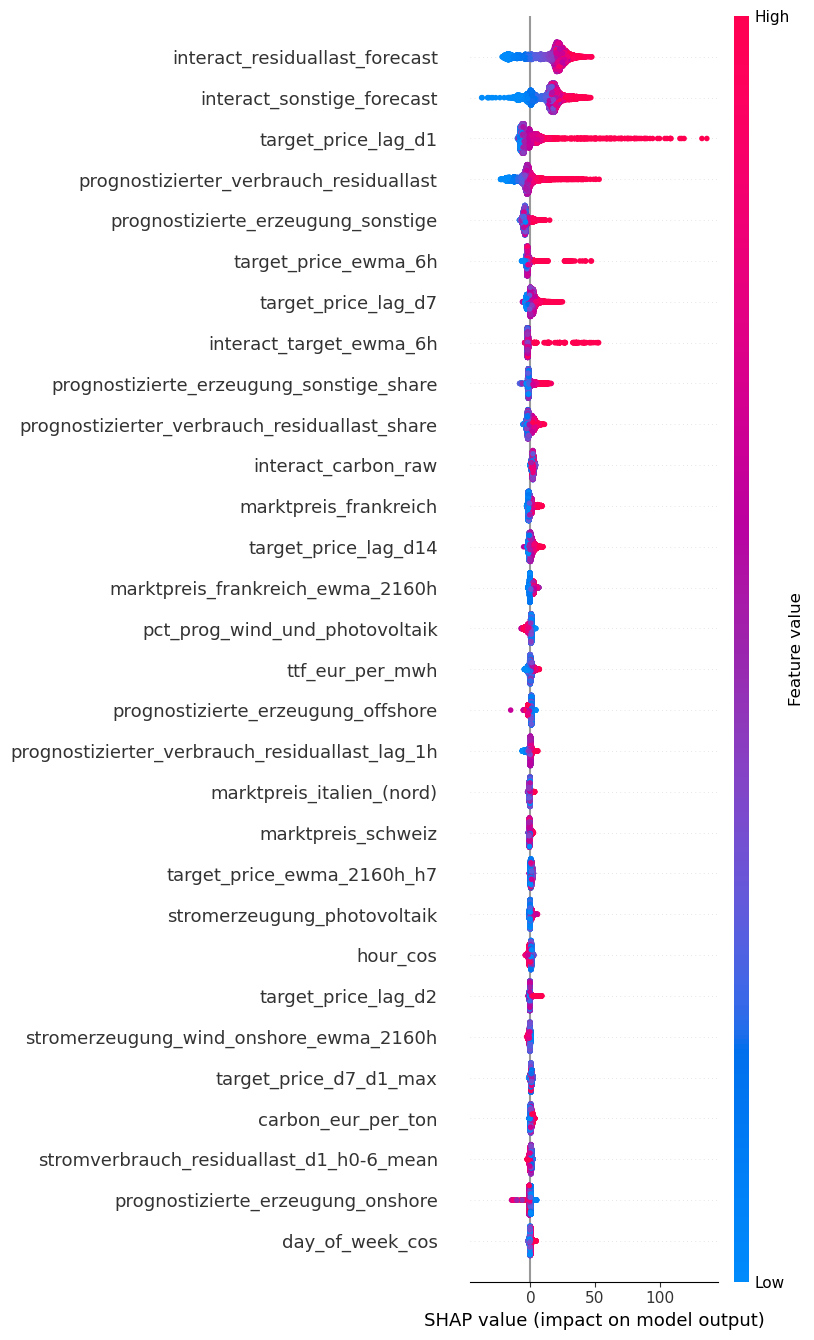

In [10]:
# SHAP beeswarm plot (top 30)
shap.summary_plot(
    shap_values,
    X_val_filled,
    max_display=30,
    show=True,
)

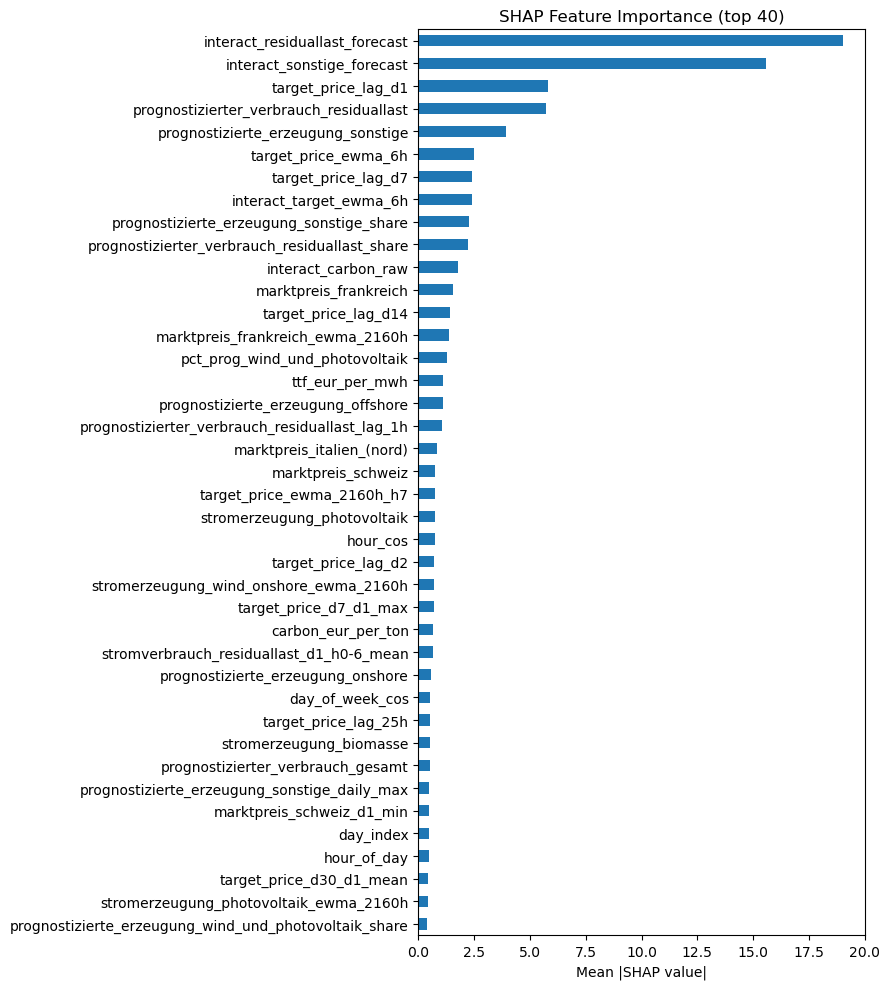


Top 50 features selected for RFECV: ['interact_residuallast_forecast', 'interact_sonstige_forecast', 'target_price_lag_d1', 'prognostizierter_verbrauch_residuallast', 'prognostizierte_erzeugung_sonstige', 'target_price_ewma_6h', 'target_price_lag_d7', 'interact_target_ewma_6h', 'prognostizierte_erzeugung_sonstige_share', 'prognostizierter_verbrauch_residuallast_share', 'interact_carbon_raw', 'marktpreis_frankreich', 'target_price_lag_d14', 'marktpreis_frankreich_ewma_2160h', 'pct_prog_wind_und_photovoltaik', 'ttf_eur_per_mwh', 'prognostizierte_erzeugung_offshore', 'prognostizierter_verbrauch_residuallast_lag_1h', 'marktpreis_italien_(nord)', 'marktpreis_schweiz', 'target_price_ewma_2160h_h7', 'stromerzeugung_photovoltaik', 'hour_cos', 'target_price_lag_d2', 'stromerzeugung_wind_onshore_ewma_2160h', 'target_price_d7_d1_max', 'carbon_eur_per_ton', 'stromverbrauch_residuallast_d1_h0-6_mean', 'prognostizierte_erzeugung_onshore', 'day_of_week_cos', 'target_price_lag_25h', 'stromerzeugung_b

In [11]:
# Bar chart of top 40
fig, ax = plt.subplots(figsize=(9, 10))
top40 = mean_abs_shap.head(40)
top40[::-1].plot(kind="barh", ax=ax)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance (top 40)")
plt.tight_layout()
plt.show()

# Ranked feature list for RFECV
shap_ranked_features = mean_abs_shap.index.tolist()
shap_top50 = shap_ranked_features[:50]
shap_top100 = shap_ranked_features[:100]
print(f"\nTop 50 features selected for RFECV: {shap_top50}")

In [20]:
# Two-stage SHAP cutoff search
# Stage 1: coarse grid
def _eval_shap_n(n):
    feats = shap_ranked_features[:n]
    m = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1,
    )
    m.fit(X_train_filled[feats], y_train, sample_weight=w_train)
    preds = m.predict(X_val_filled[feats])
    rmse = root_mean_squared_error(y_val, preds)
    return rmse, preds


coarse_grid = [10, 20, 30, 40, 50, 75, 100]
coarse_results = {}
for n in coarse_grid:
    rmse, _ = _eval_shap_n(n)
    coarse_results[n] = rmse
    print(f"    top-{n:>4}  {rmse:>8.2f}")

best_n_coarse = min(coarse_results, key=coarse_results.get)
print(f"\nCoarse best N: {best_n_coarse}  (RMSE={coarse_results[best_n_coarse]:.2f})")

# Stage 2: fine search around coarse best
fine_lo = max(2, best_n_coarse - 10)
fine_hi = best_n_coarse + 10
print(f"\nStage 2 — fine search [{fine_lo}, {fine_hi}]:")
fine_results = {}
for n in range(fine_lo, fine_hi + 1):
    rmse, _ = _eval_shap_n(n)
    fine_results[n] = rmse
    print(f"    top-{n:>4}  {rmse:>8.2f}")

best_shap_n = min(fine_results, key=fine_results.get)
print(f"\nFine best N: {best_shap_n}  (RMSE={fine_results[best_shap_n]:.2f})")

# Refit once to get final predictions for MAE/ME
best_shap_features = shap_ranked_features[:best_shap_n]
final_rmse, final_preds = _eval_shap_n(best_shap_n)
best_shap_rmse = final_rmse
best_shap_mae = mean_absolute_error(y_val, final_preds)
best_shap_me = float((final_preds - y_val.values).mean())

print(f"\nBest SHAP cutoff: top-{best_shap_n}")
print(f"  Val RMSE = {best_shap_rmse:.2f}")
print(f"  Val MAE  = {best_shap_mae:.2f}")
print(f"  Val ME   = {best_shap_me:.2f}  (bias: pred - actual)")

    top-  10     27.44
    top-  20     24.31
    top-  30     21.53
    top-  40     22.28
    top-  50     21.94
    top-  75     22.37
    top- 100     22.10

Coarse best N: 30  (RMSE=21.53)

Stage 2 — fine search [20, 40]:
    top-  20     24.31
    top-  21     24.70
    top-  22     25.17
    top-  23     24.38
    top-  24     24.63
    top-  25     23.42
    top-  26     24.03
    top-  27     23.23
    top-  28     22.44
    top-  29     21.97
    top-  30     21.53
    top-  31     22.09
    top-  32     21.55
    top-  33     21.61
    top-  34     22.39
    top-  35     21.66
    top-  36     21.88
    top-  37     22.40
    top-  38     21.73
    top-  39     22.20
    top-  40     22.28

Fine best N: 30  (RMSE=21.53)

Best SHAP cutoff: top-30
  Val RMSE = 21.53
  Val MAE  = 13.47
  Val ME   = 2.82  (bias: pred - actual)


## RFECV

Recursive Feature Elimination with Cross-Validation on the top-50 SHAP features.
Runs on the training set only — val set is held out for final comparison.

- **Estimator**: LightGBM (fast settings)
- **CV**: `TimeSeriesSplit(n_splits=3)` — no shuffle
- **Step**: 3 features removed per iteration
- **Scoring**: neg RMSE

Expected runtime: 45–90 minutes depending on hardware.

In [13]:
%%time
lgbm_rfe = clone(lgbm_base)

tscv = TimeSeriesSplit(n_splits=3)

X_top50 = X_train_filled[shap_top100]

rfecv = RFECV(
    estimator=lgbm_rfe,
    step=3,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    min_features_to_select=10,
    n_jobs=-1,
    verbose=1,
)
rfecv.fit(X_top50, y_train, sample_weight=w_train)



Fitting estimator with 100 features.
Fitting estimator with 97 features.
Fitting estimator with 94 features.
Fitting estimator with 91 features.
Fitting estimator with 88 features.
Fitting estimator with 85 features.
Fitting estimator with 82 features.
Fitting estimator with 79 features.
Fitting estimator with 76 features.
Fitting estimator with 73 features.
Fitting estimator with 70 features.
Fitting estimator with 67 features.
Fitting estimator with 64 features.
Fitting estimator with 61 features.
Fitting estimator with 58 features.
Fitting estimator with 55 features.
Fitting estimator with 52 features.
Fitting estimator with 49 features.
Fitting estimator with 46 features.
Fitting estimator with 43 features.
Fitting estimator with 40 features.
Fitting estimator with 37 features.
Fitting estimator with 34 features.
CPU times: total: 21min 1s
Wall time: 16min 24s


,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LGBMRegressor... verbose=-1)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",3
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",10
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'neg_root_mean_squared_error'
,"verbose verbose: int, default=0Controls verbosity of output.",1
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [14]:
rfecv_selected = [f for f, s in zip(shap_top100, rfecv.support_) if s]
print(f"\nRFECV selected {len(rfecv_selected)} features (from top-100 SHAP input)")
print(f"Optimal n_features: {rfecv.n_features_}")


RFECV selected 31 features (from top-100 SHAP input)
Optimal n_features: 31


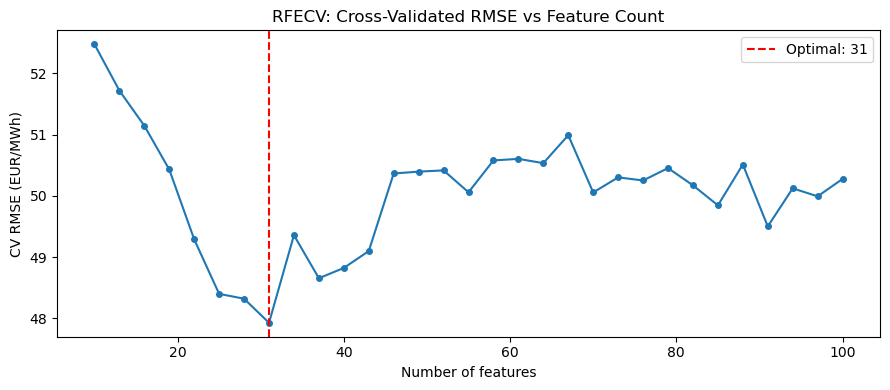


RFECV selected features:
   1. interact_residuallast_forecast  (SHAP rank #1)
   2. interact_sonstige_forecast  (SHAP rank #2)
   3. target_price_lag_d1  (SHAP rank #3)
   4. prognostizierter_verbrauch_residuallast  (SHAP rank #4)
   5. prognostizierte_erzeugung_sonstige  (SHAP rank #5)
   6. target_price_ewma_6h  (SHAP rank #6)
   7. target_price_lag_d7  (SHAP rank #7)
   8. prognostizierte_erzeugung_sonstige_share  (SHAP rank #9)
   9. prognostizierter_verbrauch_residuallast_share  (SHAP rank #10)
  10. marktpreis_frankreich_ewma_2160h  (SHAP rank #14)
  11. pct_prog_wind_und_photovoltaik  (SHAP rank #15)
  12. ttf_eur_per_mwh  (SHAP rank #16)
  13. prognostizierte_erzeugung_offshore  (SHAP rank #17)
  14. marktpreis_italien_(nord)  (SHAP rank #19)
  15. target_price_ewma_2160h_h7  (SHAP rank #21)
  16. stromerzeugung_wind_onshore_ewma_2160h  (SHAP rank #25)
  17. carbon_eur_per_ton  (SHAP rank #27)
  18. stromverbrauch_residuallast_d1_h0-6_mean  (SHAP rank #28)
  19. prognostiziert

In [15]:

# RFECV score curve
fig, ax = plt.subplots(figsize=(9, 4))
n_features_range = range(
    rfecv.min_features_to_select,
    len(shap_top100) + 1,
    rfecv.step,
)
scores = -np.array(rfecv.cv_results_["mean_test_score"])  # flip neg RMSE
ax.plot(list(n_features_range)[:len(scores)], scores, marker="o", ms=4)
ax.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal: {rfecv.n_features_}")
ax.set_xlabel("Number of features")
ax.set_ylabel("CV RMSE (EUR/MWh)")
ax.set_title("RFECV: Cross-Validated RMSE vs Feature Count")
ax.legend()
plt.tight_layout()
plt.show()

print("\nRFECV selected features:")
for i, f in enumerate(rfecv_selected, 1):
    shap_rank = shap_ranked_features.index(f) + 1
    print(f"  {i:2d}. {f}  (SHAP rank #{shap_rank})")

## Results Comparison

Compare RMSE on the held-out validation set across all feature selection methods.
Same model hyperparameters throughout for a fair comparison.

In [16]:
def eval_feature_set(name, features, X_tr, y_tr, X_va, y_va, weights):
    """Fit LightGBM on a feature subset and return RMSE, MAE, ME on val set."""
    m = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1,
    )
    avail = [f for f in features if f in X_tr.columns]
    X_tr_f = X_tr[avail].fillna(X_tr[avail].median())
    X_va_f = X_va[avail].fillna(X_tr[avail].median())
    m.fit(X_tr_f, y_tr, sample_weight=weights)
    preds = m.predict(X_va_f)
    rmse = root_mean_squared_error(y_va, preds)
    mae = mean_absolute_error(y_va, preds)
    me = float((preds - y_va.values).mean())
    return {
        "Method": name,
        "N features": len(avail),
        "Val RMSE": round(rmse, 2),
        "Val MAE": round(mae, 2),
        "Val ME": round(me, 2),
    }

results = []

# Baseline: all v5_full features (post-correlation filter)
results.append(eval_feature_set(
    "v5_full (post-corr filter)", features_after_corr,
    X_train_corr, y_train, X_val_corr, y_val, w_train,
))

# SHAP top-N subsets
for n in [20, 30, 40, 50]:
    results.append(eval_feature_set(
        f"SHAP top-{n}", shap_ranked_features[:n],
        X_train_filled, y_train, X_val_filled, y_val, w_train,
    ))

# RFECV optimal subset
results.append(eval_feature_set(
    f"RFECV ({len(rfecv_selected)} features)", rfecv_selected,
    X_train_filled, y_train, X_val_filled, y_val, w_train,
))

results_df = pd.DataFrame(results).sort_values("Val RMSE")
display(results_df)

,Method,N features,Val RMSE,Val MAE,Val ME
5,RFECV (31 features),31,21.18,12.64,0.97
2,SHAP top-30,30,21.53,13.47,2.82
4,SHAP top-50,50,21.94,13.79,5.93
0,v5_full (post-corr filter),173,21.94,13.68,4.74
3,SHAP top-40,40,22.28,14.17,4.88
1,SHAP top-20,20,24.31,16.49,9.05


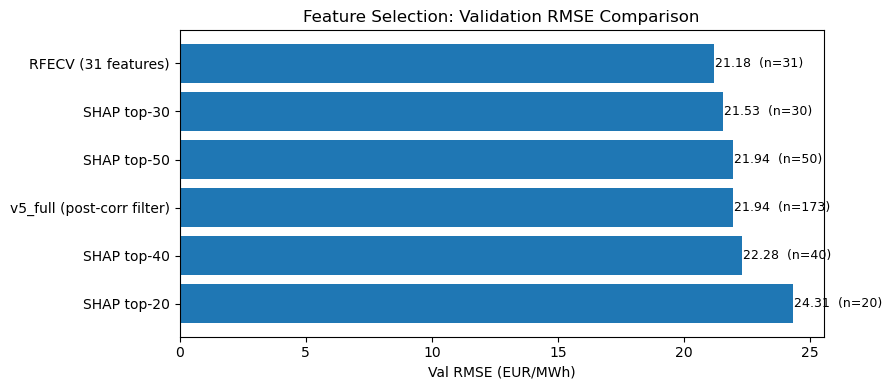

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df["Method"], results_df["Val RMSE"])
ax.set_xlabel("Val RMSE (EUR/MWh)")
ax.set_title("Feature Selection: Validation RMSE Comparison")
ax.invert_yaxis()
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(row["Val RMSE"] + 0.05, i, f"{row['Val RMSE']:.2f}  (n={row['N features']})",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Save Results

Save ranked feature lists and selection results for use in future pipeline versions.

In [18]:
import pickle

selection_results = {
    "shap_ranked": shap_ranked_features,       # all features ranked by mean |SHAP|
    "shap_top50": shap_top50,                  # top 50 (input to RFECV)
    "rfecv_selected": rfecv_selected,          # RFECV optimal subset
    "correlation_removed": corr_removed,       # features dropped by corr filter
    "results_df": results_df,                  # RMSE comparison table
    "mean_abs_shap": mean_abs_shap,            # SHAP importance scores
}

out_path = MODELS_DIR / "feature_selection_v5b_results.pkl"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(out_path, "wb") as f:
    pickle.dump(selection_results, f)

print(f"Saved to {out_path}")
print(f"\nKey outputs:")
print(f"  shap_ranked:      {len(shap_ranked_features)} features (full ranking)")
print(f"  rfecv_selected:   {len(rfecv_selected)} features (RFECV optimal)")
print(f"  corr_removed:     {len(corr_removed)} features removed by correlation filter")
print(f"\nBest method by RMSE: {results_df.iloc[0]['Method']}")


Saved to C:\Users\admin\Documents\1WBS\energy_prices\models\feature_selection_v5b_results.pkl

Key outputs:
  shap_ranked:      173 features (full ranking)
  rfecv_selected:   31 features (RFECV optimal)
  corr_removed:     19 features removed by correlation filter

Best method by RMSE: RFECV (31 features)


## Register Selected Datasets in MLflow

Use `select_columns()` to create new MLflow dataset runs for the RFECV-selected
and best-SHAP feature subsets. These can then be referenced by `blend_config.json`.

In [ ]:
from src.features.preprocessors import select_columns

# Source: the v5_full_hourly dataset with morning_cutoff_cet=7
source_run_id = meta["run_id"]
print(f"Source dataset: {source_run_id[:8]} ({meta['dataset_name']})")

# 1. RFECV-selected features (best method)
rfecv_run_id = select_columns(
    source_run_id=source_run_id,
    name="dataset_v5_full_rfecv", 
    columns=rfecv_selected,
    description=f"RFECV-selected {len(rfecv_selected)} features from v5_full (7am CET cutoff)",
)
print(f"\nRFECV dataset registered:  {rfecv_run_id[:8]}  ({len(rfecv_selected)} features)")

# 2. Best SHAP cutoff features
shap_run_id = select_columns(
    source_run_id=source_run_id,
    name="dataset_v5_full_shap_top30",
    columns=best_shap_features,
    description=f"SHAP top-{best_shap_n} features from v5_full (7am CET cutoff)",
)
print(f"SHAP dataset registered:   {shap_run_id[:8]}  ({len(best_shap_features)} features)")

print(f"\nRun IDs for blend_config.json:")
print(f"  RFECV:    {rfecv_run_id}")
print(f"  SHAP:     {shap_run_id}")